# DermaVision - Phase 6: Edge Deployment Test

## Purpose

Demonstrate that our TFLite model can run on edge devices.

In real deployment:
- Model runs on smartphone
- Patient takes photo of skin lesion
- Model predicts locally (no internet needed)
- Data never leaves device (privacy preserved)

---

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import shutil

BACKUP_DIR = 'backup/DermaVision'

# Load files
if os.path.exists('dermavision_optimized.tflite'):
    print("Loading from local...")
elif os.path.exists(os.path.join(BACKUP_DIR, 'dermavision_optimized.tflite')):
    print(f"Loading from backup ({BACKUP_DIR})...")
    shutil.copy(os.path.join(BACKUP_DIR, 'dermavision_optimized.tflite'), '.')
    if not os.path.exists('X_test.npy'):
       for file in ['X_test.npy', 'y_test.npy', 'label_classes.npy']:
           shutil.copy(os.path.join(BACKUP_DIR, file), '.')
else:
    print("ERROR: TFLite model not found! Please run 05_TFLiteOptimization.ipynb first.")

if os.path.exists('X_test.npy'):
    X_test = np.load('X_test.npy')
    y_test = np.load('y_test.npy')
    label_classes = np.load('label_classes.npy')

    if os.path.exists('dermavision_optimized.tflite'):
        interpreter = tf.lite.Interpreter(model_path='dermavision_optimized.tflite')
        interpreter.allocate_tensors()
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        print(f"Model loaded. Input: {input_details[0]['shape']}")
        print(f"Classes: {list(label_classes)}")

Loading from local...
Model loaded. Input: [  1 128 128   3]
Classes: [np.str_('invalid'), np.str_('melanoma'), np.str_('nevus'), np.str_('other')]


d:\Anaconda\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [2]:
def predict_on_device(image):
    """Simulate on-device prediction."""
    if len(image.shape) == 3:
        image = np.expand_dims(image, axis=0)
    image = image.astype(np.float32)
    
    start = time.time()
    interpreter.set_tensor(input_details[0]['index'], image)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    inference_time = (time.time() - start) * 1000
    
    pred_class = label_classes[np.argmax(output[0])]
    confidence = np.max(output[0]) * 100
    return pred_class, confidence, inference_time

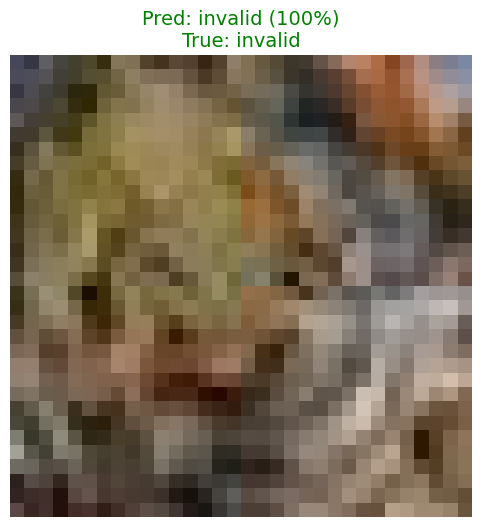

Inference time: 20.64 ms


In [3]:
# Test single image
if 'X_test' in locals():
    idx = np.random.randint(0, len(X_test))
    pred, conf, time_ms = predict_on_device(X_test[idx])
    true = label_classes[np.argmax(y_test[idx])]

    plt.figure(figsize=(6, 6))
    plt.imshow(X_test[idx])
    plt.axis('off')
    color = 'green' if pred == true else 'red'
    plt.title(f"Pred: {pred} ({conf:.0f}%)\nTrue: {true}", color=color, fontsize=14)
    plt.savefig('single_prediction.png', dpi=100)
    plt.show()
    print(f"Inference time: {time_ms:.2f} ms")

In [4]:
# Batch test
if 'X_test' in locals():
    sample_size = min(100, len(X_test))
    correct = 0
    total_time = 0

    for i in range(sample_size):
        pred, _, t = predict_on_device(X_test[i])
        true = label_classes[np.argmax(y_test[i])]
        if pred == true:
            correct += 1
        total_time += t

    accuracy = correct / sample_size * 100
    avg_time = total_time / sample_size

    print("EDGE PERFORMANCE")
    print("=" * 40)
    print(f"Accuracy: {accuracy:.1f}%")
    print(f"Avg Inference: {avg_time:.2f} ms")
    print(f"Throughput: {1000/avg_time:.1f} images/sec")

EDGE PERFORMANCE
Accuracy: 77.0%
Avg Inference: 20.05 ms
Throughput: 49.9 images/sec


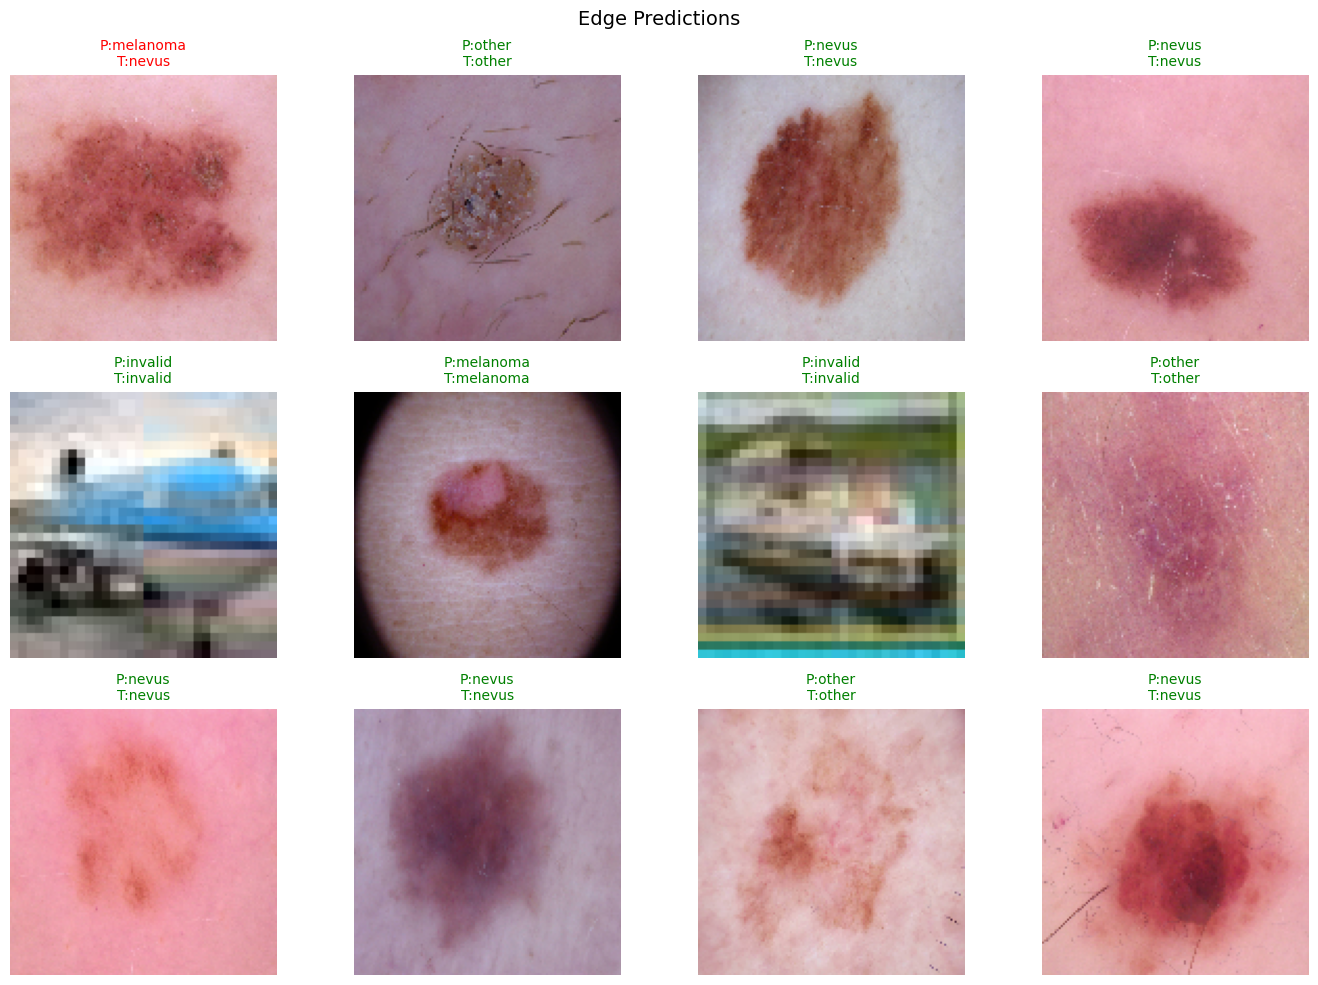

In [5]:
# Grid of predictions
if 'X_test' in locals():
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    indices = np.random.choice(len(X_test), 12, replace=False)

    for i, idx in enumerate(indices):
        row, col = i // 4, i % 4
        pred, conf, _ = predict_on_device(X_test[idx])
        true = label_classes[np.argmax(y_test[idx])]
        
        axes[row, col].imshow(X_test[idx])
        axes[row, col].axis('off')
        color = 'green' if pred == true else 'red'
        axes[row, col].set_title(f"P:{pred}\nT:{true}", fontsize=10, color=color)

    plt.suptitle('Edge Predictions', fontsize=14)
    plt.tight_layout()
    plt.savefig('edge_predictions.png', dpi=100)
    plt.show()

In [6]:
if 'accuracy' in locals():
    model_size = os.path.getsize('dermavision_optimized.tflite') / (1024*1024)

    print("\n" + "=" * 50)
    print("DERMAVISION DEPLOYMENT SUMMARY")
    print("=" * 50)
    print(f"Model Size: {model_size:.2f} MB")
    print(f"Accuracy: {accuracy:.1f}%")
    print(f"Inference: {avg_time:.2f} ms")
    print(f"Ready for mobile deployment!")
    print("=" * 50)


DERMAVISION DEPLOYMENT SUMMARY
Model Size: 2.72 MB
Accuracy: 77.0%
Inference: 20.05 ms
Ready for mobile deployment!


In [7]:
# Save final results
if 'accuracy' in locals():
    with open('edge_results.txt', 'w') as f:
        f.write("EDGE DEPLOYMENT RESULTS\n")
        f.write(f"Model Size: {model_size:.2f} MB\n")
        f.write(f"Accuracy: {accuracy:.1f}%\n")
        f.write(f"Avg Inference: {avg_time:.2f} ms\n")

    # Final backup
    os.makedirs(BACKUP_DIR, exist_ok=True)
    
    shutil.copy('single_prediction.png', BACKUP_DIR)
    shutil.copy('edge_predictions.png', BACKUP_DIR)
    shutil.copy('edge_results.txt', BACKUP_DIR)

    print(f"\nAll results backed up to {BACKUP_DIR}!")


All results backed up to backup/DermaVision!


---

## Project Complete!

### Summary

| Phase | Notebook | Purpose |
|-------|----------|--------|
| 1 | 01_DataSetup | Download and preprocess HAM10000 |
| 2 | 02_BaselineCNN | Train centralized benchmark |
| 3 | 03_FL_IID | Federated Learning with uniform data |
| 4 | 04_FL_NonIID | FL with heterogeneous data |
| 5 | 05_TFLiteOptimization | Model quantization |
| 6 | 06_EdgeDeployment | Validate deployment |
---